In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)


/opt/anaconda3/envs/rama-shap/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv("/Users/kongphopkaochot/Desktop/Senior_Project/Practical Datascience/week15/TRAIN_DATASET.csv")
test_df = pd.read_csv("/Users/kongphopkaochot/Desktop/Senior_Project/Practical Datascience/week15/TEST_DATASET.csv")


In [3]:
X_train = train_df.drop(columns=["appendicitis", "TEMP"])
y_train = train_df["appendicitis"]

X_test = test_df.drop(columns=["appendicitis", "TEMP"])
y_test = test_df["appendicitis"]

In [4]:
train_df.head(5)


,Progression,Migration,Aggravation,TEMP,Rebound,WBC,Neut,appendicitis
0,1,1,1,0,1,1,0,1
1,1,0,1,1,0,1,1,1
2,1,0,1,0,0,1,1,1
3,1,1,1,0,1,1,1,1
4,1,0,1,0,0,1,0,1


In [5]:
y_test.head(5)

0    1
1    0
2    0
3    0
4    1
Name: appendicitis, dtype: int64

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
f1_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    acc_scores.append(accuracy_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))

print("K-Fold Accuracy:", np.mean(acc_scores))
print("K-Fold F1:", np.mean(f1_scores))

K-Fold Accuracy: 0.758
K-Fold F1: 0.8389738742442135


In [7]:
final_model_no_temp = LogisticRegression(max_iter=1000)
final_model_no_temp.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [8]:
y_pred_test = final_model_no_temp.predict(X_test)
y_prob_test = final_model_no_temp.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.64      0.39      0.49       110
           1       0.78      0.91      0.84       266

    accuracy                           0.76       376
   macro avg       0.71      0.65      0.66       376
weighted avg       0.74      0.76      0.74       376

AUC: 0.7381578947368421
Confusion Matrix:
[[ 43  67]
 [ 24 242]]


In [9]:
intercept = final_model_no_temp.intercept_[0]
coefficients = final_model_no_temp.coef_[0]
features = X_train.columns

print("\n=== Logistic Regression Result ไม่มี TEMP ===")
print(f"Intercept: {intercept:.4f}")
print("-" * 45)

for name, coef in zip(features, coefficients):
    print(f"Weight of {name:15}: {coef: .4f}")

print("-" * 45)

equation = f"Logit (z) = {intercept:.4f}"

for name, coef in zip(features, coefficients):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} ({abs(coef):.4f} * {name})"

print(equation)


=== Logistic Regression Result ไม่มี TEMP ===
Intercept: -1.2648
---------------------------------------------
Weight of Progression    :  0.6160
Weight of Migration      : -0.0592
Weight of Aggravation    : -0.0114
Weight of Rebound        :  1.1058
Weight of WBC            :  0.7653
Weight of Neut           :  1.0030
---------------------------------------------
Logit (z) = -1.2648 + (0.6160 * Progression) - (0.0592 * Migration) - (0.0114 * Aggravation) + (1.1058 * Rebound) + (0.7653 * WBC) + (1.0030 * Neut)


Progression 0.21395673863496362
Migration 0.0820547361415827
Aggravation -0.047503784322739495
Rebound 0.2917212450886293
WBC 0.30821891416093444
Neut 0.3058314547201093


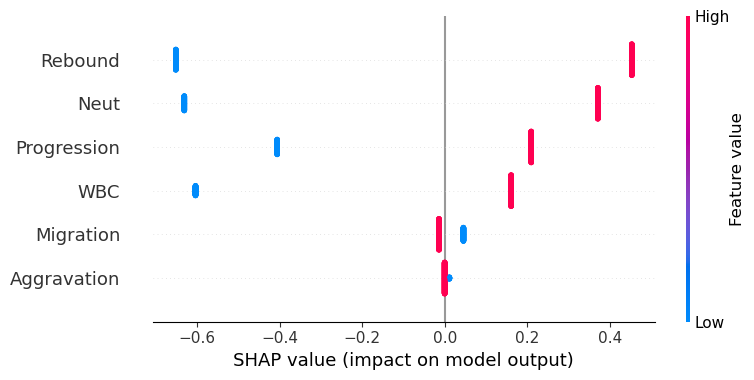

In [10]:
for col in X_train.columns:
    corr = train_df[[col, "appendicitis"]].corr().iloc[0, 1]
    print(col, corr)

# =========================
# 8) SHAP
# =========================
explainer = shap.Explainer(final_model_no_temp, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


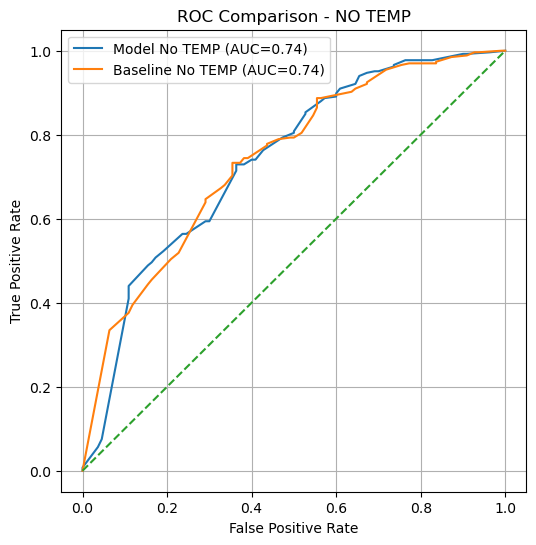

In [11]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# MODEL no TEMP ใช้ X_test
y_prob_model_no_temp = final_model_no_temp.predict_proba(X_test)[:, 1]

# DOCTOR equation no TEMP
Baseline_z_no_temp = (
    -3.37
    + 1.04 * X_test["Progression"]
    + 0.80 * X_test["Migration"]
    + 0.78 * X_test["Aggravation"]
    + 1.53 * X_test["Rebound"]
    + 0.91 * X_test["WBC"]
    + 0.69 * X_test["Neut"]
)

Baseline_prob_no_temp = sigmoid(Baseline_z_no_temp)

# ROC + AUC
fpr_model, tpr_model, _ = roc_curve(y_test, y_prob_model_no_temp)
auc_model = roc_auc_score(y_test, y_prob_model_no_temp)

fpr_doc, tpr_doc, _ = roc_curve(y_test, Baseline_prob_no_temp)
auc_doc = roc_auc_score(y_test, Baseline_prob_no_temp)

plt.figure(figsize=(6, 6))
plt.plot(fpr_model, tpr_model, label=f"Model No TEMP (AUC={auc_model:.2f})")
plt.plot(fpr_doc, tpr_doc, label=f"Baseline No TEMP (AUC={auc_doc:.2f})")
plt.plot([0, 1], [0, 1], "--")

plt.title("ROC Comparison - NO TEMP")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

<h4>โมเดลที่สร้างจากข้อมูล (data-driven model) และสมการจากผู้เชี่ยวชาญ (expert-driven model) มีพฤติกรรมต่อ feature เดียวกันแตกต่างกันได้ เนื่องจากวิธีการเรียนรู้และการใช้ข้อมูลไม่เหมือนกัน โดยในกรณีนี้ตัวแปร TEMP ซึ่งในสมการของแพทย์ถูกกำหนดให้มีน้ำหนักค่อนข้างสูง แสดงถึงความเชื่อว่ามีผลต่อการวินิจฉัย แต่เมื่อพิจารณาจากข้อมูลจริงและให้โมเดล Logistic Regression เรียนรู้จาก dataset พบว่า TEMP ไม่ได้มีอิทธิพลต่อการทำนายในระดับเดียวกัน และในบางกรณียังทำหน้าที่เป็นเพียงตัวแปรที่ช่วยปรับสมดุลร่วมกับตัวแปรอื่น เช่น WBC และ Neut มากกว่าจะเป็นตัวแปรหลักในการตัดสินใจ

เมื่อทำการตัด TEMP ออกจากโมเดล จะเห็นผลลัพธ์ที่น่าสนใจคือ ประสิทธิภาพของโมเดลที่เรียนรู้จากข้อมูลลดลงเล็กน้อย สะท้อนให้เห็นว่าแม้ TEMP จะไม่ได้มี predictive power สูงด้วยตัวมันเอง แต่ยังมีบทบาทในเชิง interaction หรือการช่วยปรับค่า decision boundary ของโมเดล อย่างไรก็ตาม ในฝั่งของสมการแพทย์ เมื่อเอา TEMP ออกกลับพบว่า AUC เพิ่มขึ้นเล็กน้อย ซึ่งสามารถตีความได้ว่าใน dataset นี้ TEMP อาจทำหน้าที่เป็น noise หรือมีข้อมูลซ้ำซ้อนกับตัวแปรอื่นอยู่แล้ว ทำให้การนำออกช่วยให้สมการมีความสอดคล้องกับข้อมูลจริงมากขึ้น</h4>